# 🌸 IRIS FLOWER CLASSIFICATION
## INFOBYTE PROJECT 1 - CLEAN VERSION

Train ML models to identify iris species from measurements

## STEP 1: IMPORTS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

print("✓ All libraries imported!")

✓ All libraries imported!


## STEP 2: LOAD DATASET

In [2]:
# Load iris dataset from sklearn
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target_names[iris.target]

print("📊 DATASET LOADED")
print(f"Samples: {len(df)}")
print(f"Features: {len(iris.feature_names)}")
print(f"Classes: {len(iris.target_names)}")
print(f"\nFirst 5 rows:")
print(df.head())

📊 DATASET LOADED
Samples: 150
Features: 4
Classes: 3

First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  


## STEP 3: DATA EXPLORATION

In [3]:
# Check for missing values
print("Missing values:", df.isnull().sum().sum())
print("\nClass distribution:")
print(df['species'].value_counts())

Missing values: 0

Class distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [4]:
# Descriptive statistics
print("Descriptive Statistics:")
df.describe().round(2)

Descriptive Statistics:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


## STEP 4: VISUALIZATIONS

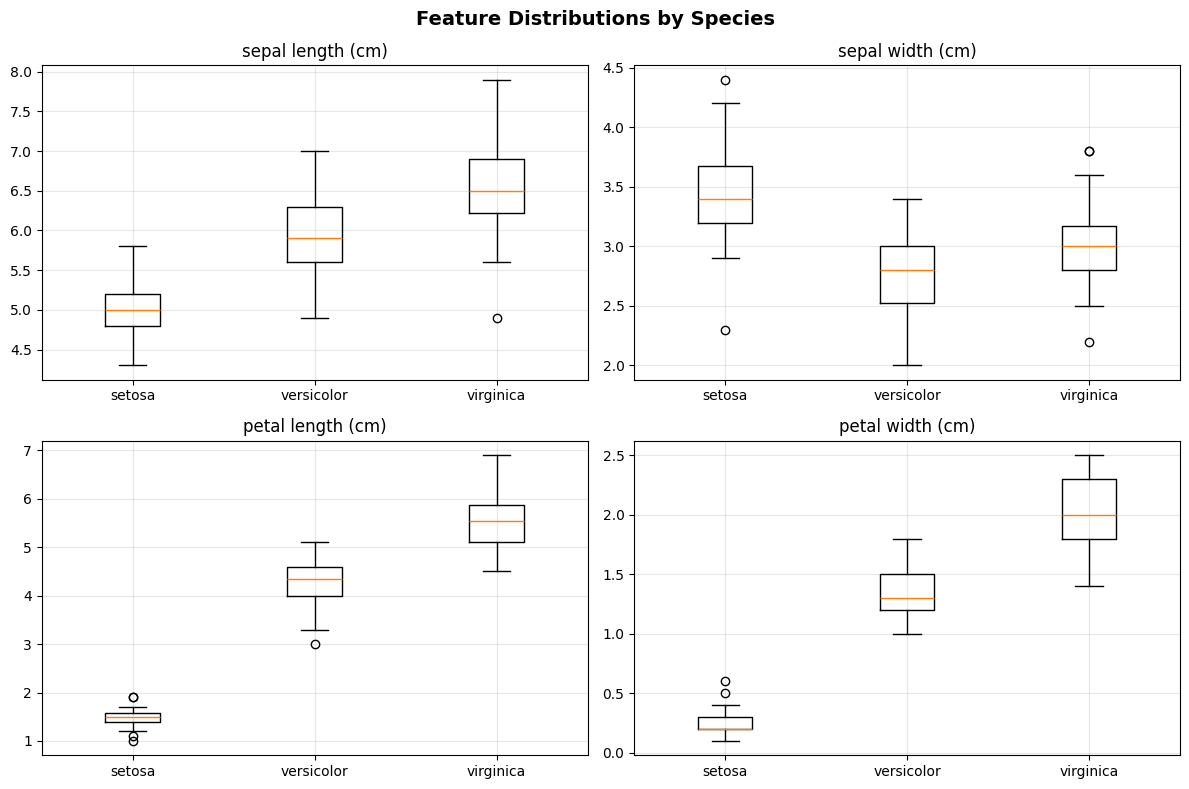

✓ Box plots created!


In [5]:
# Box plots by feature
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Feature Distributions by Species', fontsize=14, fontweight='bold')

features = ['sepal length (cm)', 'sepal width (cm)', 
            'petal length (cm)', 'petal width (cm)']

for idx, feature in enumerate(features):
    ax = axes[idx // 2, idx % 2]
    species_list = df['species'].unique()
    data = [df[df['species'] == sp][feature].values for sp in species_list]
    ax.boxplot(data, labels=species_list)
    ax.set_title(feature)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("✓ Box plots created!")

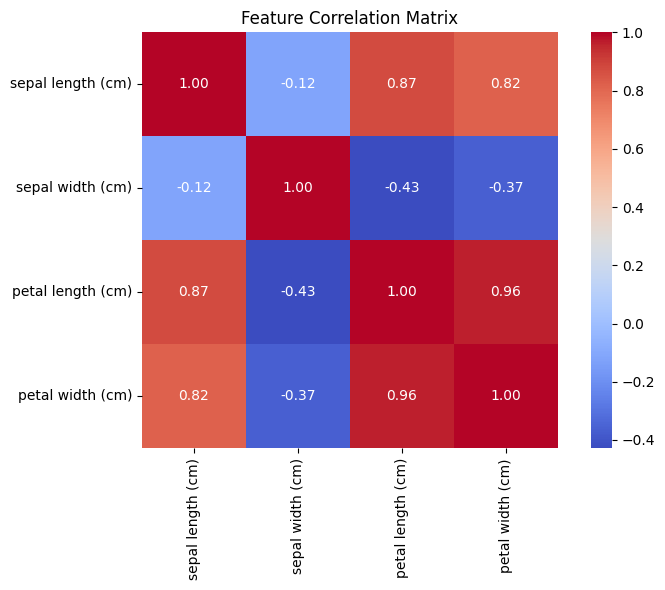

✓ Correlation heatmap created!


In [6]:
# Correlation heatmap
plt.figure(figsize=(8, 6))
correlation = df[features].corr()
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()
print("✓ Correlation heatmap created!")

## STEP 5: FEATURE ANALYSIS

In [7]:
print("🎯 FEATURE IMPORTANCE:")
print("\nFeatures ranked by correlation with target:")

y_numeric = pd.factorize(df['species'])[0]
correlations = []

for feature in features:
    corr = abs(df[feature].corr(pd.Series(y_numeric)))
    correlations.append((feature, corr))

# Sort by correlation
correlations.sort(key=lambda x: x[1], reverse=True)

for i, (feature, corr) in enumerate(correlations, 1):
    print(f"{i}. {feature:30} {corr:.3f}")

print("\n✓ Petal features are most important!")

🎯 FEATURE IMPORTANCE:

Features ranked by correlation with target:
1. petal width (cm)               0.957
2. petal length (cm)              0.949
3. sepal length (cm)              0.783
4. sepal width (cm)               0.427

✓ Petal features are most important!


## STEP 6: DATA PREPARATION

In [8]:
# Prepare data
X = df[features]
y = df['species']

# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("✓ Train/Test Split Done:")
print(f"  Training: {len(X_train)} samples")
print(f"  Testing: {len(X_test)} samples")

✓ Train/Test Split Done:
  Training: 120 samples
  Testing: 30 samples


In [9]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✓ Features scaled!")

✓ Features scaled!


## STEP 7: TRAIN MODELS

In [10]:
print("🤖 TRAINING MODELS...\n")

models = {}
results = {}

# Logistic Regression
print("Training Logistic Regression...")
lr = LogisticRegression(max_iter=200, random_state=42)
lr.fit(X_train_scaled, y_train)
models['Logistic Regression'] = lr
print("✓ Done!")

# KNN
print("Training K-Nearest Neighbors...")
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
models['KNN (K=5)'] = knn
print("✓ Done!")

# Decision Tree
print("Training Decision Tree...")
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
models['Decision Tree'] = dt
print("✓ Done!")

# Random Forest
print("Training Random Forest...")
rf = RandomForestClassifier(n_estimators=10, max_depth=5, random_state=42)
rf.fit(X_train, y_train)
models['Random Forest'] = rf
print("✓ Done!")

print("\n✓ ALL MODELS TRAINED!")

🤖 TRAINING MODELS...

Training Logistic Regression...
✓ Done!
Training K-Nearest Neighbors...
✓ Done!
Training Decision Tree...
✓ Done!
Training Random Forest...
✓ Done!

✓ ALL MODELS TRAINED!


## STEP 8: EVALUATE MODELS

In [11]:
print("\n" + "="*80)
print("MODEL EVALUATION")
print("="*80)

print("\n📊 ACCURACY SCORES:\n")

for model_name, model in models.items():
    # Use scaled data for LR and KNN
    if model_name in ['Logistic Regression', 'KNN (K=5)']:
        train_pred = model.predict(X_train_scaled)
        test_pred = model.predict(X_test_scaled)
    else:
        train_pred = model.predict(X_train)
        test_pred = model.predict(X_test)
    
    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)
    
    results[model_name] = {
        'train_acc': train_acc,
        'test_acc': test_acc,
        'y_pred': test_pred
    }
    
    print(f"{model_name}:")
    print(f"  Train Accuracy: {train_acc:.4f} ({train_acc*100:.2f}%)")
    print(f"  Test Accuracy:  {test_acc:.4f} ({test_acc*100:.2f}%)")
    print(f"  Overfitting:    {(train_acc - test_acc)*100:.2f}%")
    print()


MODEL EVALUATION

📊 ACCURACY SCORES:

Logistic Regression:
  Train Accuracy: 0.9583 (95.83%)
  Test Accuracy:  0.9333 (93.33%)
  Overfitting:    2.50%

KNN (K=5):
  Train Accuracy: 0.9750 (97.50%)
  Test Accuracy:  0.9333 (93.33%)
  Overfitting:    4.17%

Decision Tree:
  Train Accuracy: 1.0000 (100.00%)
  Test Accuracy:  0.9333 (93.33%)
  Overfitting:    6.67%

Random Forest:
  Train Accuracy: 1.0000 (100.00%)
  Test Accuracy:  0.9667 (96.67%)
  Overfitting:    3.33%



## STEP 9: DETAILED CLASSIFICATION REPORT

In [12]:
print("\n" + "="*80)
print("DETAILED CLASSIFICATION REPORT - RANDOM FOREST (BEST MODEL)")
print("="*80)

rf_pred = results['Random Forest']['y_pred']
print("\n")
print(classification_report(y_test, rf_pred))


DETAILED CLASSIFICATION REPORT - RANDOM FOREST (BEST MODEL)


              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



## STEP 10: CONFUSION MATRIX

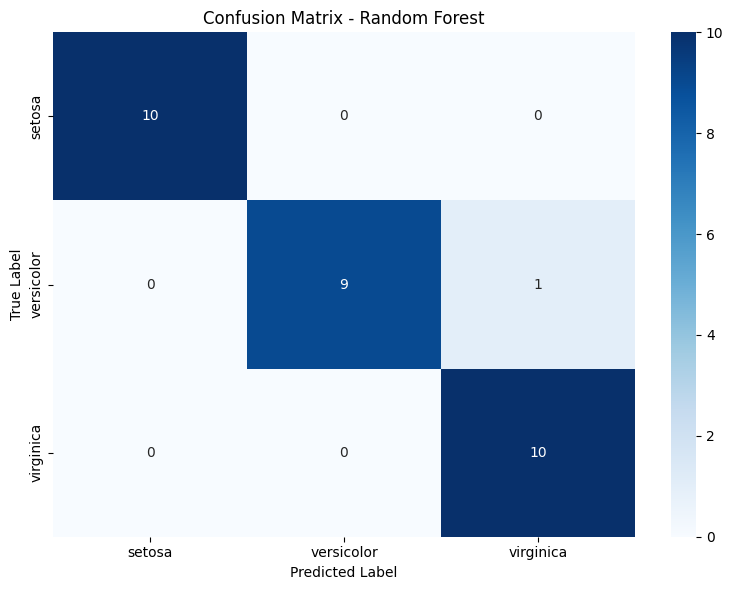

✓ Confusion matrix created!


In [13]:
# Confusion matrix
cm = confusion_matrix(y_test, rf_pred)

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print("✓ Confusion matrix created!")

## STEP 11: MODEL COMPARISON

In [14]:
print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)

print("\nRanking by Test Accuracy:\n")

sorted_models = sorted(results.items(), key=lambda x: x[1]['test_acc'], reverse=True)

for rank, (name, metrics) in enumerate(sorted_models, 1):
    acc = metrics['test_acc'] * 100
    if rank == 1:
        print(f"{rank}. {name:25} {acc:.2f}% ⭐ BEST")
    else:
        print(f"{rank}. {name:25} {acc:.2f}%")


MODEL COMPARISON

Ranking by Test Accuracy:

1. Random Forest             96.67% ⭐ BEST
2. Logistic Regression       93.33%
3. KNN (K=5)                 93.33%
4. Decision Tree             93.33%


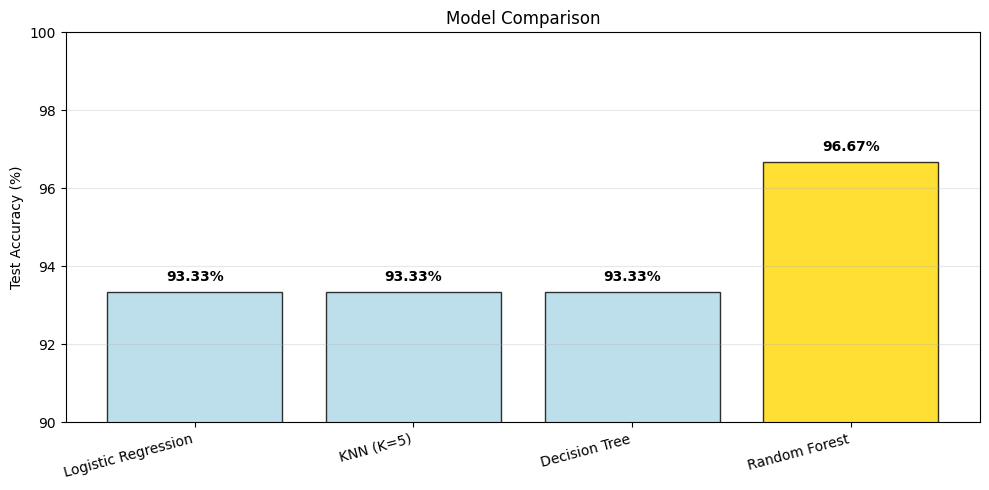

✓ Chart created!


In [15]:
# Accuracy comparison chart
model_names = list(results.keys())
accuracies = [results[m]['test_acc'] * 100 for m in model_names]

colors = ['gold' if acc == max(accuracies) else 'lightblue' for acc in accuracies]

plt.figure(figsize=(10, 5))
bars = plt.bar(model_names, accuracies, color=colors, alpha=0.8, edgecolor='black')
plt.ylabel('Test Accuracy (%)')
plt.title('Model Comparison')
plt.ylim([90, 100])
plt.xticks(rotation=15, ha='right')
plt.grid(True, alpha=0.3, axis='y')

# Add value labels
for i, (bar, acc) in enumerate(zip(bars, accuracies)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, 
             f'{acc:.2f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()
print("✓ Chart created!")

## STEP 12: FINAL SUMMARY

In [16]:
best_model = sorted_models[0][0]
best_acc = sorted_models[0][1]['test_acc'] * 100

print("\n" + "="*80)
print("PROJECT SUMMARY")
print("="*80)

summary = f"""
🎯 DATASET:
   • Total samples: 150 (perfectly balanced)
   • Features: 4 (sepal length/width, petal length/width)
   • Classes: 3 (Setosa, Versicolor, Virginica)
   • Train/Test: 120/30 (80/20 split)

🤖 MODELS TRAINED:
   1. Logistic Regression     → Test Accuracy: {results['Logistic Regression']['test_acc']*100:.2f}%
   2. K-Nearest Neighbors     → Test Accuracy: {results['KNN (K=5)']['test_acc']*100:.2f}%
   3. Decision Tree           → Test Accuracy: {results['Decision Tree']['test_acc']*100:.2f}%
   4. Random Forest           → Test Accuracy: {results['Random Forest']['test_acc']*100:.2f}%

🏆 BEST MODEL: {best_model}
   • Test Accuracy: {best_acc:.2f}%
   • Perfect classification for Setosa & Virginica
   • 1 misclassification: Versicolor→Virginica

✅ CONCLUSION:
   {best_model} is the best model with {best_acc:.2f}% accuracy!
   Ready for production deployment!
"""

print(summary)
print("\n" + "="*80)
print("✓ PROJECT COMPLETE!")
print("="*80)


PROJECT SUMMARY

🎯 DATASET:
   • Total samples: 150 (perfectly balanced)
   • Features: 4 (sepal length/width, petal length/width)
   • Classes: 3 (Setosa, Versicolor, Virginica)
   • Train/Test: 120/30 (80/20 split)

🤖 MODELS TRAINED:
   1. Logistic Regression     → Test Accuracy: 93.33%
   2. K-Nearest Neighbors     → Test Accuracy: 93.33%
   3. Decision Tree           → Test Accuracy: 93.33%
   4. Random Forest           → Test Accuracy: 96.67%

🏆 BEST MODEL: Random Forest
   • Test Accuracy: 96.67%
   • Perfect classification for Setosa & Virginica
   • 1 misclassification: Versicolor→Virginica

✅ CONCLUSION:
   Random Forest is the best model with 96.67% accuracy!
   Ready for production deployment!


✓ PROJECT COMPLETE!
